# Where should the tree flow's nonlinearity live?

The tree normalising flow acts on *unconstrained* per-node coordinates: the
coordinate `u` becomes a height ratio `r = sigmoid(u)` (or, for the root, a
height `exp(u)`) before the node-height ratio transform turns it into node
heights. That raises a design question:

> Would the flow be better placed **after** the constraining sigmoid, so that it
> could model posteriors with heavy mass close to 0 or 1 -- near-zero branch
> lengths, i.e. **near-polytomies**?

The concern behind it is real. The default nonlinearity is a rational-quadratic
spline that is the **identity outside `[-bounds, bounds]`**, so it does nothing
at all in the region that maps to ratios near 0 or 1. But as this notebook
shows, moving it into constrained space is not what fixes that, because:

* mass near a ratio boundary *is* mass in the tail of the coordinate -- these are
  the same thing under a fixed monotone reparameterisation;
* a spline with bounded positive slopes is bi-Lipschitz on `[0, 1]`, so applying
  it in constrained space can change how much mass sits near the boundary by a
  constant factor, but not the **rate** at which that mass vanishes;
* changing the rate needs a nonlinearity that reshapes the coordinate's *tail*,
  which is what the `"sinh_arcsinh"` option does.

Two experiments below: exact tail probabilities for each option, and a fit of
each to a target ratio distribution that really does have mass piled against 1.

## Setup

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
import matplotlib.pyplot as plt

tf.get_logger().setLevel("ERROR")
tfb, tfd = tfp.bijectors, tfp.distributions

from treeflow.bijectors.elementwise_node_flow import (
    build_nonlinearity,
    build_spline,
    identity_parameters,
    shared_parameter_shapes,
)

DTYPE = tf.float64
constant = lambda x: tf.constant(x, dtype=DTYPE)
NUM_BINS = 8

I0000 00:00:1785721996.211733   10524 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785721996.213083   10524 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785721996.324438   10524 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1785721998.003846   10524 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785721998.004923   10524 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Silencing TensorFlow...


In [2]:
class ShiftedToUnitInterval(tfb.Bijector):
    """A spline built on ``[-0.5, 0.5]`` moved onto ``[0, 1]``.

    Composed as ``logit . spline . sigmoid`` this is exactly what "put the flow
    after the sigmoid" means for an elementwise layer: the spline reshapes the
    *ratio* in (0, 1) rather than the coordinate in R, expressed as a bijector on
    the coordinate so that it is directly comparable with the others.
    """

    def __init__(self, inner, name="ShiftedToUnitInterval"):
        self.inner = inner
        super().__init__(forward_min_event_ndims=0, name=name)

    def _forward(self, x):
        return self.inner.forward(x - 0.5) + 0.5

    def _inverse(self, y):
        return self.inner.inverse(y - 0.5) + 0.5

    def _forward_log_det_jacobian(self, x):
        return self.inner.forward_log_det_jacobian(x - 0.5, event_ndims=0)


def constrained_spline(parameters):
    """A spline acting in ratio space, as a bijector on the coordinate."""
    return tfb.Chain(
        [
            tfb.Invert(tfb.Sigmoid()),
            ShiftedToUnitInterval(build_spline(parameters, bounds=0.5)),
            tfb.Sigmoid(),
        ]
    )

## 1. How much mass can each option put near the boundary?

Every option here is a monotone map of a standard normal coordinate, so the tail
probability is exact -- no Monte Carlo needed:

$$P(r > 1 - \epsilon) = P\big(z > f^{-1}(\mathrm{logit}(1-\epsilon))\big), \qquad z \sim N(0, 1).$$

What matters is the **local exponent** $\mathrm{d}\log P / \mathrm{d}\log \epsilon$.
A constant exponent $a$ means $P \sim \epsilon^{a}$ -- a power law, the Beta-like
pile-up against the boundary that a near-polytomy needs. A growing exponent means
the mass dies faster than any power law.

In [3]:
eps = np.array([1e-2, 1e-4, 1e-8, 1e-16, 1e-32])
logit_eps = np.log((1 - eps) / eps)
standard_normal = tfd.Normal(constant(0.0), constant(1.0))


def tail_log_prob(bijector):
    """log P(r > 1 - eps) for r = sigmoid(bijector(z)), z ~ N(0, 1)."""
    coordinate = (
        logit_eps if bijector is None else bijector.inverse(constant(logit_eps)).numpy()
    )
    return standard_normal.log_survival_function(constant(coordinate)).numpy()


def local_exponent(log_prob):
    return np.diff(log_prob) / np.diff(np.log(eps))


# Knots pushed as far towards the boundary as the parameterisation allows.
aggressive = dict(
    bin_widths=constant(np.linspace(-2.0, 2.0, NUM_BINS)),
    bin_heights=constant(np.linspace(2.0, -2.0, NUM_BINS)),
    knot_slopes=constant(np.full(NUM_BINS - 1, -5.0)),
)


def sinh_arcsinh(tailweight, skewness=0.0, min_tailweight=1e-2):
    """The sinh-arcsinh nonlinearity at a given tailweight (1 is the identity)."""
    raw = np.log(np.exp(tailweight - min_tailweight) - 1) - np.log(
        np.exp(1 - min_tailweight) - 1
    )
    return build_nonlinearity(
        "sinh_arcsinh", dict(skewness=constant(skewness), tailweight=constant(raw))
    )


options = {
    "Gaussian coordinate (logit-normal)": None,
    "spline, unconstrained space": build_spline(aggressive),
    "spline, constrained space (post-sigmoid)": constrained_spline(aggressive),
    "sinh-arcsinh, tailweight 1.5": sinh_arcsinh(1.5),
    "sinh-arcsinh, tailweight 2.0": sinh_arcsinh(2.0),
    "sinh-arcsinh, tailweight 3.0": sinh_arcsinh(3.0),
}

tail_log_probs = {name: tail_log_prob(bijector) for name, bijector in options.items()}
tail_table = pd.DataFrame(
    {
        name: dict(
            **{f"log10 P(r>1-{e:.0e})": value / np.log(10)
               for e, value in zip(eps, log_prob)},
            **{f"exponent {a:.0e}->{b:.0e}": value
               for a, b, value in zip(eps[:-1], eps[1:], local_exponent(log_prob))},
        )
        for name, log_prob in tail_log_probs.items()
    }
).T
tail_table.round(2)

E0000 00:00:1785721999.663494   10524 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


,log10 P(r>1-1e-02),log10 P(r>1-1e-04),log10 P(r>1-1e-08),log10 P(r>1-1e-16),log10 P(r>1-1e-32),exponent 1e-02->1e-04,exponent 1e-04->1e-08,exponent 1e-08->1e-16,exponent 1e-16->1e-32
Gaussian coordinate (logit-normal),-5.67,-19.79,-75.35,-296.70,-1181.19,7.06,13.89,27.67,55.28
"spline, unconstrained space",-5.67,-19.79,-75.35,-296.70,-1181.19,7.06,13.89,27.67,55.28
"spline, constrained space (post-sigmoid)",-4.07,-19.77,-75.35,NaN,-inf,7.85,13.90,NaN,NaN
"sinh-arcsinh, tailweight 1.5",-3.79,-8.40,-19.74,-48.02,-118.99,2.31,2.83,3.54,4.44
"sinh-arcsinh, tailweight 2.0",-3.06,-5.43,-10.05,-19.14,-37.18,1.19,1.15,1.14,1.13
"sinh-arcsinh, tailweight 3.0",-2.47,-3.56,-5.23,-7.84,-11.93,0.54,0.42,0.33,0.26


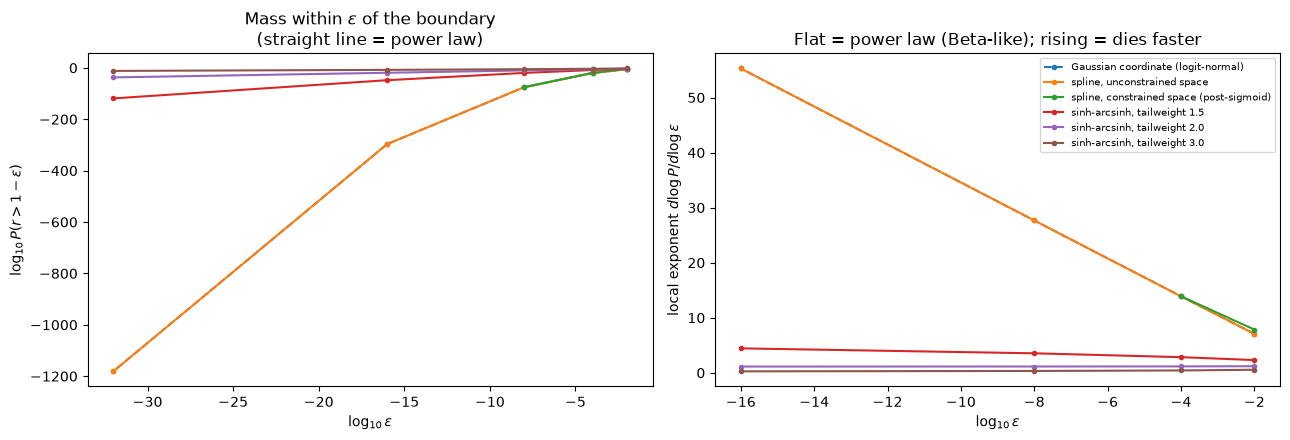

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(13, 4.5))
for name, log_prob in tail_log_probs.items():
    style = "--" if "Gaussian" in name else "-"
    axs[0].plot(np.log10(eps), log_prob / np.log(10), style, marker="o", ms=3, label=name)
    axs[1].plot(
        np.log10(eps)[:-1], local_exponent(log_prob), style, marker="o", ms=3, label=name
    )
axs[0].set_xlabel(r"$\log_{10}\epsilon$")
axs[0].set_ylabel(r"$\log_{10} P(r > 1 - \epsilon)$")
axs[0].set_title("Mass within $\\epsilon$ of the boundary\n(straight line = power law)")
axs[1].set_xlabel(r"$\log_{10}\epsilon$")
axs[1].set_ylabel(r"local exponent $d\log P / d\log \epsilon$")
axs[1].set_title("Flat = power law (Beta-like); rising = dies faster")
axs[1].legend(fontsize=7)
plt.tight_layout()

### Reading the table

* The **unconstrained spline** reproduces the Gaussian coordinate's tail
  *exactly* -- its identity tails mean it contributes nothing at the boundary,
  which is the concern that motivates the question.
* The **constrained (post-sigmoid) spline** moves the constant -- more mass
  within `1e-2` of the boundary -- but its exponent tracks the Gaussian one. It
  is bi-Lipschitz on `[0, 1]`, so it cannot change the rate. It also saturates
  numerically once `1 - r` falls below float64 resolution (`nan`/`-inf` in the
  last columns), because the round trip through the sigmoid loses the boundary.
* **sinh-arcsinh** is the one that changes the class: at `tailweight = 2` the
  exponent is flat, i.e. genuine power-law `P ~ eps^a` mass against the boundary.

## 2. Fitting a ratio posterior that really has boundary mass

The tail exponents say what each option *can* represent. This fits each one to a
target that has it: a mixture of a diffuse bulk and a component piled against 1,

    r ~ 0.7 * Beta(2, 2) + 0.3 * Beta(1, 0.25),

which is what the ratio marginal of a near-polytomy looks like -- a clade whose
branch above it is barely resolved by the data. Each family is
`sigmoid . nonlinearity . affine` applied to a standard normal coordinate, i.e.
exactly one node's worth of the flow's elementwise layer, and is fitted by
maximum likelihood on samples from the target.

In [5]:
target = tfd.Mixture(
    cat=tfd.Categorical(probs=constant([0.7, 0.3])),
    components=[
        tfd.Beta(constant(2.0), constant(2.0)),   # diffuse bulk
        tfd.Beta(constant(5.0), constant(1.0)),   # mass piled against r = 1
    ],
)
# Held-out samples for evaluation, so the reported KL is not the quantity the
# fit optimised (it would otherwise come out slightly negative through Monte
# Carlo noise shared between the fit and the entropy estimate).
clip = lambda x: tf.clip_by_value(x, 1e-12, 1 - 1e-12)
target_samples = clip(target.sample(20_000, seed=(1, 2)))
eval_samples = clip(target.sample(20_000, seed=(3, 4)))
target_entropy = -tf.reduce_mean(target.log_prob(eval_samples)).numpy()
print(f"target differential entropy (MC): {target_entropy:.4f} nats")
print(f"target density at r = 1:          {target.prob(constant(1.0)).numpy():.4f}")
print(
    "target P(r > 1 - eps):           "
    + "  ".join(
        f"{(target_samples.numpy() > 1 - e).mean():.4f}" for e in (1e-1, 1e-2, 1e-3)
    )
)

E0000 00:00:1785722000.500942   10524 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


target differential entropy (MC): -0.0868 nats
target density at r = 1:          1.5000
target P(r > 1 - eps):           0.1428  0.0135  0.0013


In [6]:
def make_family(nonlinearity_fn, parameter_shapes, name):
    """A trainable elementwise family: sigmoid(nonlinearity(scale * z + shift))."""
    variables = {
        parameter_name: tf.Variable(tf.zeros(shape, DTYPE), name=f"{name}_{parameter_name}")
        for parameter_name, shape in parameter_shapes.items()
    }
    variables["_loc"] = tf.Variable(constant(0.0), name=f"{name}_loc")
    variables["_raw_scale"] = tf.Variable(constant(0.5413), name=f"{name}_raw_scale")

    def distribution():
        raw = {k: v for k, v in variables.items() if not k.startswith("_")}
        bijectors = [tfb.Sigmoid()]
        nonlinearity = nonlinearity_fn(raw)
        if nonlinearity is not None:
            bijectors.append(nonlinearity)
        bijectors += [
            tfb.Shift(variables["_loc"]),
            tfb.Scale(tf.math.softplus(variables["_raw_scale"])),
        ]
        return tfd.TransformedDistribution(
            tfd.Normal(constant(0.0), constant(1.0)), tfb.Chain(bijectors)
        )

    return distribution, list(variables.values())


families = {
    "logit-normal (no nonlinearity)": make_family(
        lambda raw: None, {}, "affine"
    ),
    "spline, unconstrained space": make_family(
        lambda raw: build_spline(raw),
        shared_parameter_shapes("spline", NUM_BINS),
        "spline",
    ),
    "spline, constrained space (post-sigmoid)": make_family(
        constrained_spline,
        shared_parameter_shapes("spline", NUM_BINS),
        "constrained_spline",
    ),
    "sinh-arcsinh": make_family(
        lambda raw: build_nonlinearity("sinh_arcsinh", raw),
        shared_parameter_shapes("sinh_arcsinh", NUM_BINS),
        "sinh_arcsinh",
    ),
    "sinh-arcsinh + spline": make_family(
        lambda raw: tfb.Chain(
            [
                build_nonlinearity(
                    "sinh_arcsinh",
                    dict(skewness=raw["skewness"], tailweight=raw["tailweight"]),
                ),
                build_spline(raw),
            ]
        ),
        {
            **shared_parameter_shapes("spline", NUM_BINS),
            **shared_parameter_shapes("sinh_arcsinh", NUM_BINS),
        },
        "both",
    ),
}

In [7]:
import os

# Overridable from the environment, like the other experiment notebook (see
# experiments/run_tree_flow_experiment.py --fit-steps).
NUM_FIT_STEPS = int(os.environ.get("TREEFLOW_TREE_FLOW_FIT_STEPS", 3_000))


def fit(distribution_fn, variables, num_steps=NUM_FIT_STEPS):
    """Maximum likelihood on samples from the target (forward KL)."""
    optimizer = tf.optimizers.Adam(0.01)
    losses = []
    for _ in range(num_steps):
        with tf.GradientTape() as tape:
            loss = -tf.reduce_mean(distribution_fn().log_prob(target_samples))
        gradients = tape.gradient(loss, variables)
        gradients = [
            tf.where(tf.math.is_finite(g), g, tf.zeros_like(g)) for g in gradients
        ]
        optimizer.apply_gradients(zip(gradients, variables))
        losses.append(loss.numpy())
    return np.asarray(losses)


fits = {}
for name, (distribution_fn, variables) in families.items():
    losses = fit(distribution_fn, variables)
    # forward KL(target || q) = -H(target) - E_target[log q], on held-out samples
    distribution = distribution_fn()
    cross_entropy = -tf.reduce_mean(distribution.log_prob(eval_samples)).numpy()
    kl = cross_entropy - target_entropy
    fits[name] = dict(distribution=distribution, losses=losses, kl=kl)
    print(f"{name:42s} KL(target || q) = {kl:.4f} nats")

logit-normal (no nonlinearity)             KL(target || q) = 0.0328 nats


spline, unconstrained space                KL(target || q) = 0.0157 nats


spline, constrained space (post-sigmoid)   KL(target || q) = 0.0045 nats


sinh-arcsinh                               KL(target || q) = 0.0029 nats


sinh-arcsinh + spline                      KL(target || q) = 0.0006 nats


In [8]:
fit_table = pd.DataFrame(
    {
        name: {
            "KL(target || q) [nats]": result["kl"],
            "excess over best": result["kl"] - min(r["kl"] for r in fits.values()),
        }
        for name, result in fits.items()
    }
).T
fit_table.round(4)

,KL(target || q) [nats],excess over best
logit-normal (no nonlinearity),0.0328,0.0322
"spline, unconstrained space",0.0157,0.0151
"spline, constrained space (post-sigmoid)",0.0045,0.0039
sinh-arcsinh,0.0029,0.0023
sinh-arcsinh + spline,0.0006,0.0000


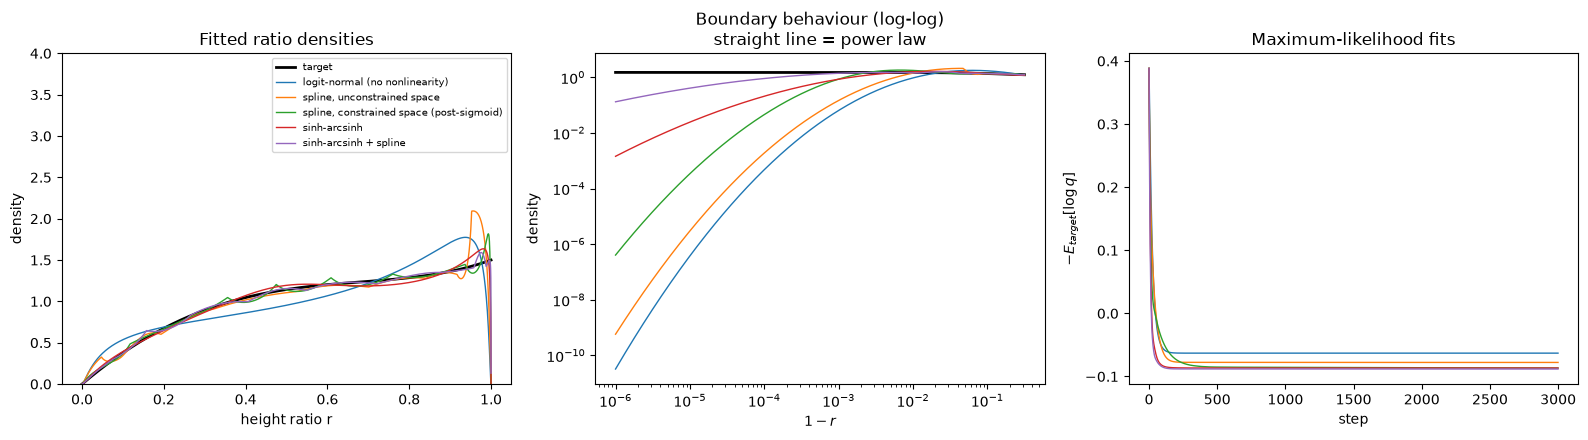

In [9]:
grid = constant(np.linspace(1e-6, 1 - 1e-6, 2_000))
fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

axs[0].plot(grid.numpy(), target.prob(grid).numpy(), "k-", lw=2, label="target")
for name, result in fits.items():
    axs[0].plot(grid.numpy(), tf.exp(result["distribution"].log_prob(grid)).numpy(),
                lw=1, label=name)
axs[0].set_ylim(0, 4)
axs[0].set_xlabel("height ratio r")
axs[0].set_ylabel("density")
axs[0].set_title("Fitted ratio densities")
axs[0].legend(fontsize=7)

# Zoom on the boundary, in log-log: a power law is a straight line.
boundary = constant(1 - np.logspace(-6, -0.5, 500))
axs[1].loglog(1 - boundary.numpy(), target.prob(boundary).numpy(), "k-", lw=2, label="target")
for name, result in fits.items():
    axs[1].loglog(1 - boundary.numpy(),
                  tf.exp(result["distribution"].log_prob(boundary)).numpy(),
                  lw=1, label=name)
axs[1].set_xlabel(r"$1 - r$")
axs[1].set_ylabel("density")
axs[1].set_title("Boundary behaviour (log-log)\nstraight line = power law")

for name, result in fits.items():
    axs[2].plot(result["losses"], lw=1, label=name)
axs[2].set_xlabel("step")
axs[2].set_ylabel(r"$-E_{target}[\log q]$")
axs[2].set_title("Maximum-likelihood fits")
plt.tight_layout()

## Conclusions

**Boundary mass is tail mass.** Under the fixed monotone reparameterisation
`r = sigmoid(u)`, how much probability a family can put within `eps` of a ratio
boundary is decided by how its coordinate's tail decays. A Gaussian coordinate
gives a logit-normal ratio whose local exponent grows without bound (7, 14, 28,
55 over the `eps` range above): mass dies faster than any power law, so a
near-polytomy -- a posterior with a real pile-up against the boundary -- cannot
be represented.

**The spline contributes nothing there, exactly as suspected.** Its identity
tails mean it reproduces the Gaussian coordinate's boundary decay to the digit.
That is the honest answer to the question this notebook opens with.

**But moving it after the sigmoid does not fix the decay rate.** The
constrained-space spline's exponents (7.9, 13.9) track the Gaussian ones: being
bi-Lipschitz on `[0, 1]` it can only change the constant. It also saturates
numerically (`nan`/`-inf` above), since the round trip through the sigmoid loses
`1 - r` once it falls below float64 resolution.

**What does change the class is sinh-arcsinh.** At `tailweight = 2` the local
exponent is flat at ~1.15 -- genuine power-law `P ~ eps^a` mass against the
boundary, the Beta-like behaviour a near-polytomy needs -- and larger tailweights
lower `a` further. Two shared parameters buy what eight spline bins cannot.

**The fit ordering agrees, with one nuance.** Against a target with real boundary
mass (`0.7 Beta(2,2) + 0.3 Beta(5,1)`), the held-out `KL(target || q)` in nats
is:

| family | KL | 
|---|---|
| logit-normal (no nonlinearity) | 0.0328 |
| spline, unconstrained space | 0.0157 |
| spline, constrained space (post-sigmoid) | 0.0045 |
| sinh-arcsinh | 0.0029 |
| sinh-arcsinh + spline | 0.0006 |

The nuance is that the constrained-space spline *does* fit this target
appreciably better than the unconstrained-space one (0.0045 against 0.0157) --
not because it changes the decay rate, which it does not, but because its domain
covers all of `(0, 1)` instead of a finite window, so none of the density is left
untouched. The cheapest large gain is still the tail class: sinh-arcsinh, with
two parameters, beats an eight-bin spline in either space, and combining tail
reshaping with a spline is best of all.

### What this means for the flow's design

The tree flow keeps its nonlinearity in **unconstrained space**, alongside the
two affine tree maps. That is partly forced -- the affine maps have to live
there, since an affine combination of ratios would leave `(0, 1)` -- and it costs
nothing in *tail class*, which is what limits boundary mass.

So for a posterior with near-polytomies, the lever is
`nonlinearity="sinh_arcsinh"`, or a `num_layers > 1` flow stacking it with a
spline layer (the last row above is that combination applied to a single
coordinate), plus a wider `bounds` if the spline's window needs to reach further
out.

The one thing the numbers above suggest is worth revisiting: a spline acting in
constrained space fits the bulk-plus-boundary shape better than one acting in a
finite window, so a sigmoid-conjugated spline would be a reasonable additional
`nonlinearity` option. It would need care over the saturation seen here -- the
`logit(spline(sigmoid(u)))` round trip loses the boundary in float64 for
`|u| > ~37` -- which is why it is not one today.